In [3]:
from util import go_to_project_root
go_to_project_root()

CWD cambiado a la raíz del proyecto: c:\Users\PC_829\Documents\GitHub\HW2


# Tarea 3: Aplicacion de test de raiz unitaria en Series de Tiempo

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from source.data.loaders import create_dataset
from source.fit import inference as testmodule
from source.display.hw import hw3 as plot_utils
from source.display.hw.hw1 import save_figure
plot_utils.configure_matplotlib_for_latex()

%load_ext autoreload
%autoreload 2

LaTeX está disponible y la configuración se ha aplicado.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Cargando los datos

El archivo `base_25.xls` contiene informacion mensual de: 
- $Y$: IMACEC , 
- $P$: IPC  
- $I$ Tasa de Politica Monetaria 

Considere las series cuya `::key` asociada al diccionario de datos se muestra a continuacion
- `p`: $\ln(P_t)$, 
- `y`: $\ln(Y_t)$, 
- `dtp`: $\Delta \ln(P_t)$, 
- `dty`: $\Delta \ln(Y_t)$, 
- `i`: $i_t = I_t/100$.
- `t`: periodo $t$

In [5]:
dataset = create_dataset('./data/base_25.xls', problem=6)

[INFO] ¡Datos cargados exitosamente!


✅ Figura guardada exitosamente en ./presentation/figures/hw3/series_raw.pdf


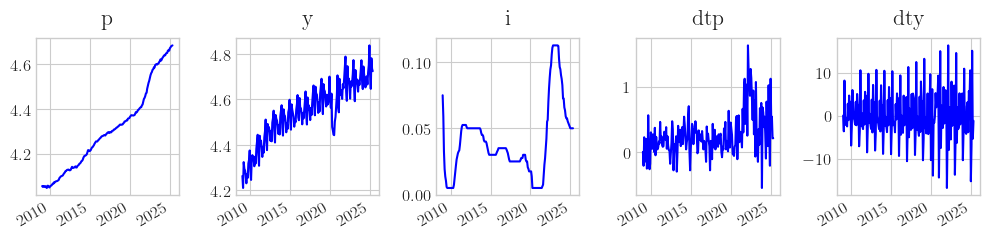

In [8]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=5, 
    figsize=(10, 2.5), 
)
fig, axes = plot_utils.plot_series(dataset, fig=fig, axes=axes)
save_figure(fig, './presentation/figures/hw3/series_raw.pdf')

## Test 1: DF (Dickey-Fuller)

In [6]:
testmodule.test_df()

Test DF


## Test 2: ADF (Augmented Dickey-Fuller)

In [8]:
testmodule.test_adf()

Test ADF


## Test 3: PP (Phillips-Perron)

In [14]:
testmodule.test_pp(dataset['p'])

,Metrica,Valor
0,Estadistico Zrho Case1,0.147807
1,Valor P Zrho Case1,0.377451
2,rho estimado Case1,1.000754
3,Valor Critico 1% Case1,-11.8
4,Valor Critico 5% Case1,-7.3
5,Valor Critico 10% Case1,-5.3
6,Estadistico Zrho Case2,1.112853
7,Valor P Zrho Case2,0.239954
8,rho estimado Case2,1.005828
9,Valor Critico 1% Case2,-13.8


## Test 4: KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

In [11]:
testmodule.test_kpss()

Test KPSS


## Test 5: Perron

In [12]:
testmodule.test_perron()

Test Perron


## Test 6: Zivot-Andrews

In [13]:
testmodule.test_zivot_andrews()

Test Zivot-Andrews


## Test 7: Bierens

In [14]:
testmodule.test_bierens()

Test Bierens


## Test 8: Murray and Nelson

In [15]:
testmodule.test_murray_nelson()

Test Murray-Nelson


## Test 9: GLS detrending

In [16]:
testmodule.test_gls()

Test GLS
